In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input, AdditiveAttention, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mahadidn/wind-speed-forecasting/refs/heads/main/datasets/1994_2025_multivariat.csv')
df.head(5)

,TANGGAL,TAVG,RH_AVG,FF_AVG
0,1994-03-01,28.4,72.0,11.0
1,1994-03-02,27.7,76.0,10.0
2,1994-03-03,27.7,79.0,9.0
3,1994-03-04,26.0,90.0,5.0
4,1994-03-05,23.3,96.0,3.0


In [3]:
# Pembagian data 70% training, 20% validasi, dan 10% testing
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.20)
n_test  = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df   = df.iloc[n_train : n_train + n_val].copy()
test_df  = df.iloc[n_train + n_val :].copy()

print(f"Total: {n}, Train: {n_train}, Val: {n_val}, Test: {n_test}")

# Cek tanggal berapa saja yang dipakai
print("Training range:", train_df['TANGGAL'].min(), "–", train_df['TANGGAL'].max())
print("Validation range:", val_df['TANGGAL'].min(), "–", val_df['TANGGAL'].max())
print("Testing range:", test_df['TANGGAL'].min(), "–", test_df['TANGGAL'].max())

Total: 11354, Train: 7947, Val: 2270, Test: 1137
Training range: 1994-03-01 – 2015-12-02
Validation range: 2015-12-03 – 2022-02-18
Testing range: 2022-02-19 – 2025-03-31


In [4]:
# fitur dan target
input_features = ['FF_AVG', 'TAVG', 'RH_AVG']
target_feature = 'FF_AVG'

print(f"Input features: {input_features}")
print(f"Target feature: {target_feature}")

Input features: ['FF_AVG', 'TAVG', 'RH_AVG']
Target feature: FF_AVG


In [5]:
X_train = train_df[input_features].values
X_val = val_df[input_features].values
X_test = test_df[input_features].values

y_train = train_df[target_feature].values
y_val = val_df[target_feature].values
y_test = test_df[target_feature].values

print(f"\nData shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")



Data shapes:
X_train: (7947, 3), y_train: (7947,)
X_val: (2270, 3), y_val: (2270,)
X_test: (1137, 3), y_test: (1137,)


In [6]:
# Data scaling menggunakan min-max
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Save scalers
os.makedirs('models', exist_ok=True)
with open("models/X_scaler_multivariate.pkl", "wb") as f:
    pickle.dump(X_scaler, f)

with open("models/y_scaler_multivariate.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

In [7]:
# membuat sliding window untuk multistep forecasting
def create_multistep_sequences(X, y, time_steps, forecast_horizon):
    """Create sequences for multi-step multivariate time series prediction"""
    if len(X) <= time_steps + forecast_horizon:
        raise ValueError(f"Panjang data ({len(X)}) harus lebih dari time_steps + forecast_horizon ({time_steps + forecast_horizon})")

    Xs, ys = [], []
    for i in range(len(X) - time_steps - forecast_horizon + 1):
        # Input sequence multivariat (time_steps, n_features)
        Xs.append(X[i : (i + time_steps)])
        # Output sequence: univariat (forecast_horizon,)
        ys.append(y[i + time_steps : i + time_steps + forecast_horizon])

    return np.array(Xs), np.array(ys)

# Multi-step forecasting parameters
time_steps = 60        # menggunakan 60 hari data historis
forecast_horizon = 30  # prediksi 30 hari ke depan

# Buat multi-step sequences (MULTIVARIAT)
X_train_seq, y_train_seq = create_multistep_sequences(X_train_scaled, y_train_scaled, time_steps, forecast_horizon)
X_val_seq, y_val_seq = create_multistep_sequences(X_val_scaled, y_val_scaled, time_steps, forecast_horizon)
X_test_seq, y_test_seq = create_multistep_sequences(X_test_scaled, y_test_scaled, time_steps, forecast_horizon)

print(f"\nMultivariate sequences shapes:")
print(f"Multi-step sequences shapes:")
print(f"X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq: {X_val_seq.shape}, y_val_seq: {y_val_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}, y_test_seq: {y_test_seq.shape}")


Multivariate sequences shapes:
Multi-step sequences shapes:
X_train_seq: (7858, 60, 3), y_train_seq: (7858, 30)
X_val_seq: (2181, 60, 3), y_val_seq: (2181, 30)
X_test_seq: (1048, 60, 3), y_test_seq: (1048, 30)


In [8]:
# Model BiLSTM-Attention untuk MULTIVARIAT
def create_multivariate_bilstm_attention(units=64, time_steps=60, forecast_horizon=30, n_layers=2, n_features=3):
    """
    Buat model BiLSTM-Attention untuk multivariate input, univariate output

    Parameters:
    - units: jumlah units dalam LSTM layer
    - forecast_horizon: jumlah steps untuk prediksi
    - n_layers: jumlah BiLSTM layers
    - n_features: jumlah input features (3 untuk FF_AVG, TAVG, RH_AVG)
    """

    # Input shape: (time_steps, n_features)
    input_shape = (time_steps, n_features)
    inputs = Input(shape=input_shape, name='multivariate_input')

    print(f"Model input shape: {input_shape}")

    x = inputs

    # Multiple BiLSTM layers
    for i in range(n_layers):
        x = Bidirectional(
            LSTM(units,
                 activation='relu',
                 return_sequences=True,
                 name=f'lstm_{i+1}'),
            name=f'bilstm_{i+1}'
        )(x)

    # x shape sekarang: (batch_size, time_steps, 2*units)
    bilstm_output = x

    # Attention mechanism
    context_vector = AdditiveAttention(name='attention_layer')([bilstm_output, bilstm_output])

    # Global average pooling untuk reduksi dimensi
    context_vector = GlobalAveragePooling1D(name='global_pooling')(context_vector)

    # Fully connected layers
    dense_1 = Dense(64, activation='relu', name='dense_1')(context_vector)

    # Output layer: univariate prediction untuk forecast_horizon steps
    output = Dense(forecast_horizon, activation='linear', name='forecast_output')(dense_1)

    # Create model
    model = Model(inputs=inputs, outputs=output, name='Multivariate_BiLSTM_Attention')

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss='mae',
        metrics=['mae', 'mse']
    )

    return model

# Membuat model multivariat
print("\nMembangun Multivariate BiLSTM-Attention model...")
model = create_multivariate_bilstm_attention(
    units=64,
    time_steps=time_steps,
    forecast_horizon=forecast_horizon,
    n_layers=2,
    n_features=len(input_features)
)

model.summary()


Membangun Multivariate BiLSTM-Attention model...
Model input shape: (60, 3)


Model: "Multivariate_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ multivariate_input  │ (None, 60, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 60, 128)   │     34,816 │ multivariate_inp… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 60, 128)   │     98,816 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 60, 128)   │        128 │ bilstm_2[0][0],   │
│ (AdditiveAttention) │                   │            │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pooling      │ (None, 128)       │          0 │ attention_layer[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_pooling[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 30)        │      1,950 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,966 (562.37 KB)

 Trainable params: 143,966 (562.37 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Callbacks
# jika tidak ada perubahan pada proses training turunkan nilai learning rate agar konvergen
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.000001,
    verbose=1
)

# Training
print("\nStarting multivariate model training...")
history_multistep = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[reduce_lr],
    shuffle=False,
    verbose=1
)

# Save model and history
try:
    model.save('models/multivariate_model.keras')
    print("Multivariate model berhasil disimpan!")

    with open('models/multivariate_history.pkl', 'wb') as f:
        pickle.dump(history_multistep.history, f)
    print("Training history berhasil disimpan!")

except Exception as e:
    print(f"Error saving model: {e}")


Starting multivariate model training...
Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 27s 66ms/step - loss: 0.1661 - mae: 0.1661 - mse: 0.0547 - val_loss: 0.0935 - val_mae: 0.0935 - val_mse: 0.0123 - learning_rate: 0.0010
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1122 - mae: 0.1122 - mse: 0.0220 - val_loss: 0.1070 - val_mae: 0.1070 - val_mse: 0.0159 - learning_rate: 0.0010
Epoch 3/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1077 - mae: 0.1077 - mse: 0.0200 - val_loss: 0.1045 - val_mae: 0.1045 - val_mse: 0.0152 - learning_rate: 0.0010
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.1058 - mae: 0.1058 - mse: 0.0190 - val_loss: 0.0984 - val_mae: 0.0984 - val_mse: 0.0137 - learning_rate: 0.0010
Epoch 5/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1044 - mae: 0.1044 - mse: 0.0185 - val_loss: 0.0970 - val_mae: 0.0970 - val_mse: 0.0133 - learning_rate: 0.0010
Epoch 6/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1031 - mae: 

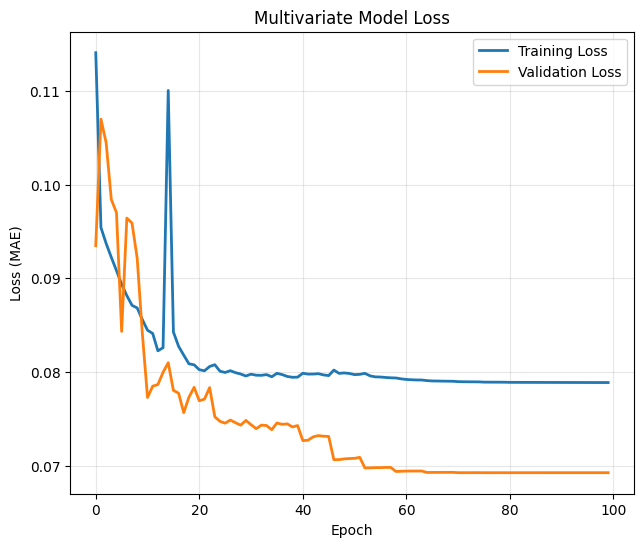

In [10]:
# Plot training history
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_multistep.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_multistep.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Multivariate Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.legend()
plt.grid(True, alpha=0.3)

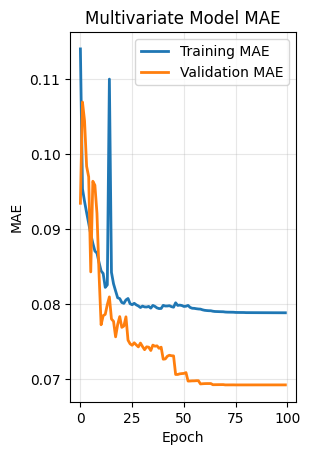

In [11]:
plt.subplot(1, 2, 2)
plt.plot(history_multistep.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history_multistep.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Multivariate Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

In [12]:
plt.tight_layout()
plt.savefig('models/multivariate_training_history.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [13]:
# Evaluasi Multi-step
def calculate_multistep_metrics(y_true, y_pred):
    """Hitung metrik evaluasi untuk multi-step forecasting"""

    metrics = {}
    n_steps = y_true.shape[1]

    # Keseluruhan metrik
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    metrics['keseluruhan'] = {
        'mae': mean_absolute_error(y_true_flat, y_pred_flat),
        'mape': mean_absolute_percentage_error(y_true_flat, y_pred_flat) * 100,
        'rmse': np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    }

    # metrik tiap langkah
    metrics['langkah'] = {}
    for step in range(n_steps):
        step_true = y_true[:, step]
        step_pred = y_pred[:, step]

        metrics['langkah'][f'step_{step+1}'] = {
            'mae': mean_absolute_error(step_true, step_pred),
            'mape': mean_absolute_percentage_error(step_true, step_pred) * 100,
            'rmse': np.sqrt(mean_squared_error(step_true, step_pred))
        }

    return metrics


In [14]:
# Evaluasi model multivariat
print("\nMaking multivariate predictions...")
try:
    y_pred_multistep_scaled = model.predict(X_test_seq, verbose=0)
    print(f"Prediction shape: {y_pred_multistep_scaled.shape}")

    # Inverse transform ke skala asli
    n_samples, n_steps = y_pred_multistep_scaled.shape
    y_pred_multistep_reshaped = y_pred_multistep_scaled.reshape(-1, 1)
    y_test_seq_reshaped = y_test_seq.reshape(-1, 1)

    y_pred_multistep_original = y_scaler.inverse_transform(y_pred_multistep_reshaped).reshape(n_samples, n_steps)
    y_test_seq_original = y_scaler.inverse_transform(y_test_seq_reshaped).reshape(n_samples, n_steps)

    # Hitung metrics
    multivariate_metrics = calculate_multistep_metrics(y_test_seq_original, y_pred_multistep_original)

    # Display results
    print("\n" + "=" * 70)
    print("=== HASIL EVALUASI MULTIVARIATE MULTI-STEP FORECASTING ===")
    print("=" * 70)
    print(f"Input Features: {input_features}")
    print(f"Target Feature: {target_feature}")

    print("\n--- Keseluruhan Performa ---")
    keseluruhan = multivariate_metrics['keseluruhan']
    print(f'Mean Absolute Error (MAE):     {keseluruhan["mae"]:.4f} m/s')
    print(f'Mean Absolute Percentage Error (MAPE): {keseluruhan["mape"]:.2f}%')
    print(f'Root Mean Square Error (RMSE): {keseluruhan["rmse"]:.4f} m/s')

    print(f"\n--- Performa per langkah ({forecast_horizon} hari ke depan) ---")
    print(f"{'Step':<6} {'MAE':<8} {'MAPE(%)':<10} {'RMSE':<8}")
    print("-" * 40)

    for step_name, step_metrics in multivariate_metrics['langkah'].items():
        step_num = step_name.split('_')[1]
        print(f"{step_num:<6} {step_metrics['mae']:<8.4f} {step_metrics['mape']:<10.2f} "
              f"{step_metrics['rmse']:<8.4f}")

    print("=" * 70)

    # Simpan detail prediksi
    predictions_detailed = []
    for i in range(len(y_test_seq_original)):
        for step in range(forecast_horizon):
            predictions_detailed.append({
                'sampel_idx': i,
                'forecast_step': step + 1,
                'aktual': y_test_seq_original[i, step],
                'prediksi': y_pred_multistep_original[i, step],
                'selisih': y_test_seq_original[i, step] - y_pred_multistep_original[i, step],
                'abs_error': abs(y_test_seq_original[i, step] - y_pred_multistep_original[i, step])
            })

    predictions_df = pd.DataFrame(predictions_detailed)
    predictions_df.to_csv('models/multivariate_predictions.csv', index=False)
    print("Detail hasil prediksi tersimpan ke models/multivariate_predictions.csv")

    # Save metrics
    with open('models/multivariate_metrics.pkl', 'wb') as f:
        pickle.dump(multivariate_metrics, f)
    print("Metrik berhasil tersimpan ke models/multivariate_metrics.pkl")

except Exception as e:
    print(f"Error during evaluation: {e}")
    raise


Making multivariate predictions...
Prediction shape: (1048, 30)

=== HASIL EVALUASI MULTIVARIATE MULTI-STEP FORECASTING ===
Input Features: ['FF_AVG', 'TAVG', 'RH_AVG']
Target Feature: FF_AVG

--- Keseluruhan Performa ---
Mean Absolute Error (MAE):     0.6757 m/s
Mean Absolute Percentage Error (MAPE): 26.28%
Root Mean Square Error (RMSE): 0.9889 m/s

--- Performa per langkah (30 hari ke depan) ---
Step   MAE      MAPE(%)    RMSE    
----------------------------------------
1      0.5868   23.66      0.8762  
2      0.6088   24.34      0.9053  
3      0.6251   24.63      0.9306  
4      0.6331   25.25      0.9339  
5      0.6478   25.52      0.9565  
6      0.6496   25.65      0.9579  
7      0.6480   25.40      0.9550  
8      0.6571   25.45      0.9669  
9      0.6525   25.46      0.9585  
10     0.6552   25.58      0.9621  
11     0.6616   25.72      0.9715  
12     0.6685   25.91      0.9810  
13     0.6742   26.12      0.9897  
14     0.6740   26.08      0.9897  
15     0.6814   2

In [15]:
# Plot sample forecasting
def plot_sample_predictions(y_true, y_pred, n_samples=1, save_path='models/sample_predictions.png'):
    """Plot sample multi-step forecasting"""
    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 4*n_samples))
    if n_samples == 1:
        axes = [axes]

    for i in range(min(n_samples, len(y_true))):
        axes[i].plot(range(1, forecast_horizon+1), y_true[i], 'bo-', label='Aktual', linewidth=2)
        axes[i].plot(range(1, forecast_horizon+1), y_pred[i], 'ro-', label='Prediksi', linewidth=2)
        axes[i].set_title(f'Prediksi 30 langkah kedepan')
        axes[i].set_xlabel('Time steps (Harian)')
        axes[i].set_ylabel('Kecepatan Angin (m/s)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)


    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"plot sampel prediksi tersimpan ke {save_path}")


plot sampel prediksi tersimpan ke models/sample_predictions.png


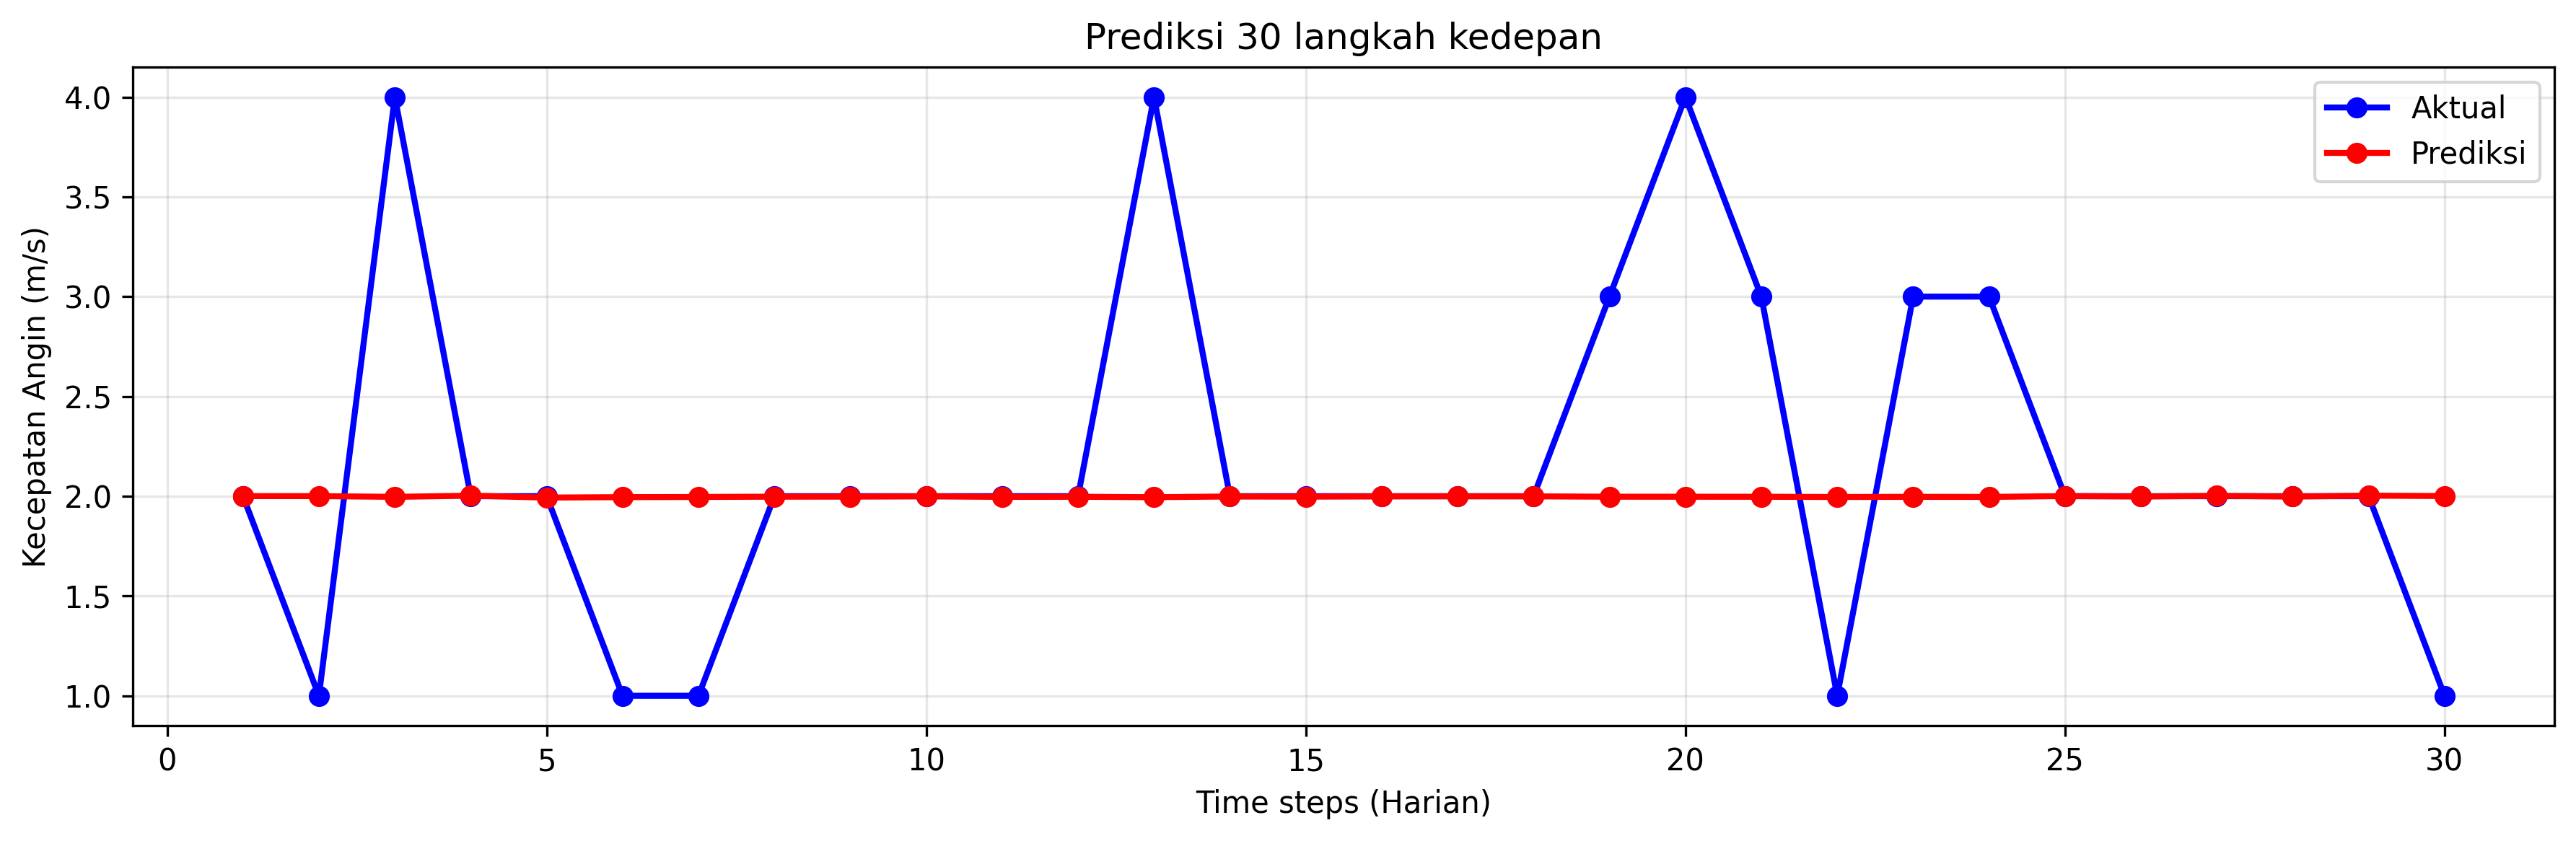

In [16]:
# Buat plot
plot_sample_predictions(y_test_seq_original, y_pred_multistep_original)
display(Image(filename='models/sample_predictions.png'))

In [17]:
# Prediksi real-time dengan model multivariat
def predict_next_n_steps_multivariate(latest_sequence, model, X_scaler, y_scaler,
                                     time_steps=60, forecast_horizon=30):
    """
    Prediksi 30 langkah ke depan menggunakan model multivariat.

    Parameters:
    - latest_sequence: ndarray, shape (time_steps, n_features) - data multivariat
    - model: trained keras model
    - X_scaler: fitted MinMaxScaler untuk fitur
    - y_scaler: fitted MinMaxScaler untuk target
    - time_steps: panjang jendela waktu
    - forecast_horizon: jumlah langkah ke depan yang ingin diprediksi

    Returns:
    - pred_original: ndarray, shape (forecast_horizon,) - prediksi dalam skala asli
    """
    if latest_sequence.shape[0] != time_steps:
        raise ValueError(f"Data harus berjumlah {time_steps} baris, "
                        f"data yang diinputkan berjumlah {latest_sequence.shape[0]}")

    if latest_sequence.shape[1] != len(input_features):
        raise ValueError(f"Data harus memiliki {len(input_features)} kolom features, "
                        f"data yang diinputkan memiliki {latest_sequence.shape[1]} kolom")

    # Normalisasi data multivariat
    latest_scaled = X_scaler.transform(latest_sequence)

    # Reshape untuk prediksi (1, time_steps, n_features)
    input_seq = np.expand_dims(latest_scaled, axis=0)

    # Prediksi
    pred_scaled = model.predict(input_seq, verbose=0)[0]  # shape: (forecast_horizon,)

    # Inverse transform ke skala asli
    pred_original = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    return pred_original

In [18]:
# Ambil urutan terakhir dari dataset untuk prediksi real-time
print(f"\nPrediksi real-time menggunakan data {time_steps} hari terakhir...")
latest_sequence_multivariate = df[input_features].values[-time_steps:]

print(f"Input data shape: {latest_sequence_multivariate.shape}")
print(f"Input features: {input_features}")
print(f"Input data summary:")
for i, feature in enumerate(input_features):
    data_col = latest_sequence_multivariate[:, i]
    print(f"  {feature}: min={data_col.min():.2f}, max={data_col.max():.2f}, mean={data_col.mean():.2f}")

# Prediksi 30 hari ke depan
next_30_forecast_multivariate = predict_next_n_steps_multivariate(
    latest_sequence=latest_sequence_multivariate,
    model=model,
    X_scaler=X_scaler,
    y_scaler=y_scaler,
    time_steps=time_steps,
    forecast_horizon=forecast_horizon
)

print(f"\nPrediksi kecepatan angin 30 hari ke depan (model multivariat):")
for i, value in enumerate(next_30_forecast_multivariate, start=1):
    print(f"Hari {i:2d}: {value:.2f} m/s")



Prediksi real-time menggunakan data 60 hari terakhir...
Input data shape: (60, 3)
Input features: ['FF_AVG', 'TAVG', 'RH_AVG']
Input data summary:
  FF_AVG: min=2.00, max=6.00, mean=4.00
  TAVG: min=23.70, max=29.00, mean=27.63
  RH_AVG: min=73.00, max=97.00, mean=81.58

Prediksi kecepatan angin 30 hari ke depan (model multivariat):
Hari  1: 2.77 m/s
Hari  2: 2.82 m/s
Hari  3: 2.81 m/s
Hari  4: 2.79 m/s
Hari  5: 2.76 m/s
Hari  6: 2.76 m/s
Hari  7: 2.73 m/s
Hari  8: 2.74 m/s
Hari  9: 2.70 m/s
Hari 10: 2.75 m/s
Hari 11: 2.74 m/s
Hari 12: 2.74 m/s
Hari 13: 2.70 m/s
Hari 14: 2.70 m/s
Hari 15: 2.71 m/s
Hari 16: 2.63 m/s
Hari 17: 2.64 m/s
Hari 18: 2.62 m/s
Hari 19: 2.70 m/s
Hari 20: 2.63 m/s
Hari 21: 2.61 m/s
Hari 22: 2.63 m/s
Hari 23: 2.59 m/s
Hari 24: 2.57 m/s
Hari 25: 2.63 m/s
Hari 26: 2.56 m/s
Hari 27: 2.56 m/s
Hari 28: 2.59 m/s
Hari 29: 2.58 m/s
Hari 30: 2.57 m/s


In [19]:
# load csv untuk data aktual terbaru 30 hari kedepan
next_30_actual = pd.read_csv('https://raw.githubusercontent.com/mahadidn/wind-speed-forecasting/refs/heads/main/datasets/next-30.csv')
array_next_30_actual = next_30_actual['FF_AVG'].values
print(array_next_30_actual)

[3 3 3 3 2 3 2 2 3 2 3 2 2 3 2 3 1 2 2 1 2 2 1 1 3 2 2 3 2 3]


In [20]:
# hitung metrik error data aktual dan prediksi 30 hari kedepan
# Hitung error
mae_future = mean_absolute_error(array_next_30_actual, next_30_forecast_multivariate)
mape_future = mean_absolute_percentage_error(array_next_30_actual, next_30_forecast_multivariate) * 100
rmse_future = np.sqrt(mean_squared_error(array_next_30_actual, next_30_forecast_multivariate))

print(f"\nPerbandingan dengan data aktual 30 hari ke depan:")
print(f"MAE: {mae_future:.4f} m/s")
print(f"MAPE: {mape_future:.2f}%")
print(f"RMSE: {rmse_future:.4f} m/s")



Perbandingan dengan data aktual 30 hari ke depan:
MAE: 0.6442 m/s
MAPE: 41.00%
RMSE: 0.7709 m/s


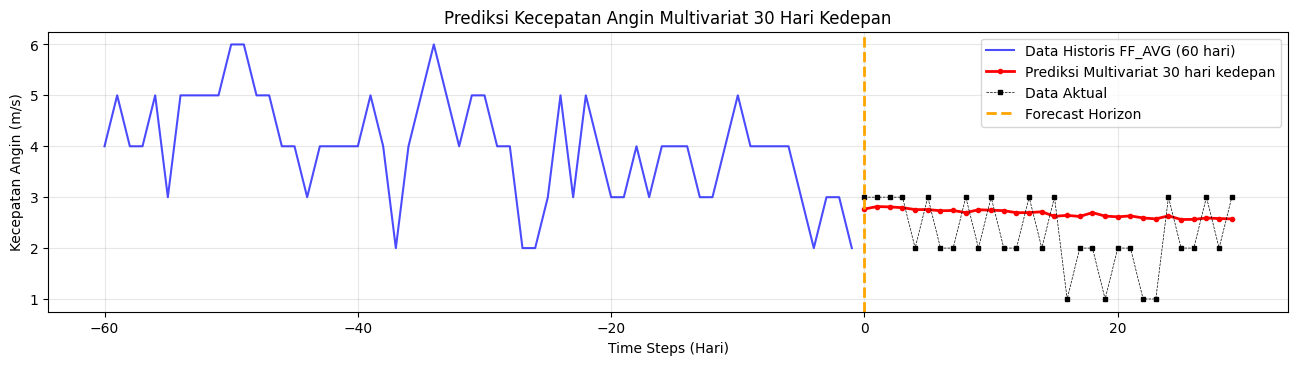

In [21]:
# Visualisasi prediksi masa depan
plt.figure(figsize=(16, 8))

# Plot data historis sebagai konteks (hanya target variable)
context_data = latest_sequence_multivariate[:, 0]  # ambil FF_AVG saja untuk konteks
context_x = range(-len(context_data), 0)
future_x = range(0, len(next_30_forecast_multivariate))

plt.subplot(2, 1, 1)
plt.plot(context_x, context_data, label='Data Historis FF_AVG (60 hari)', color='blue', alpha=0.7)
plt.plot(future_x, next_30_forecast_multivariate, label='Prediksi Multivariat 30 hari kedepan', color='red', linewidth=2, marker='o', markersize=3)
plt.plot(future_x, array_next_30_actual, label='Data Aktual', color='black', linestyle='--', linewidth=0.5, marker='s', markersize=3)

plt.axvline(x=0, color='orange', linestyle='--', linewidth=2, label='Forecast Horizon')
plt.title('Prediksi Kecepatan Angin Multivariat 30 Hari Kedepan')
plt.xlabel('Time Steps (Hari)')
plt.ylabel('Kecepatan Angin (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)


In [22]:
# load csv untuk data aktual terbaru 30 hari kedepan
next_56_actual = pd.read_csv('https://raw.githubusercontent.com/mahadidn/wind-speed-forecasting/refs/heads/main/datasets/next-56.csv')
array_next_56_actual = next_56_actual['FF_AVG'].values
print(array_next_56_actual)

[3 3 3 3 2 3 2 2 3 2 3 2 2 3 2 3 1 2 2 1 2 2 1 1 3 2 2 3 2 3 1 2 3 2 1 2 2
 1 1 2 2 1 2 1 2 2 2 1 2 2 2 1 2 2 3 2]


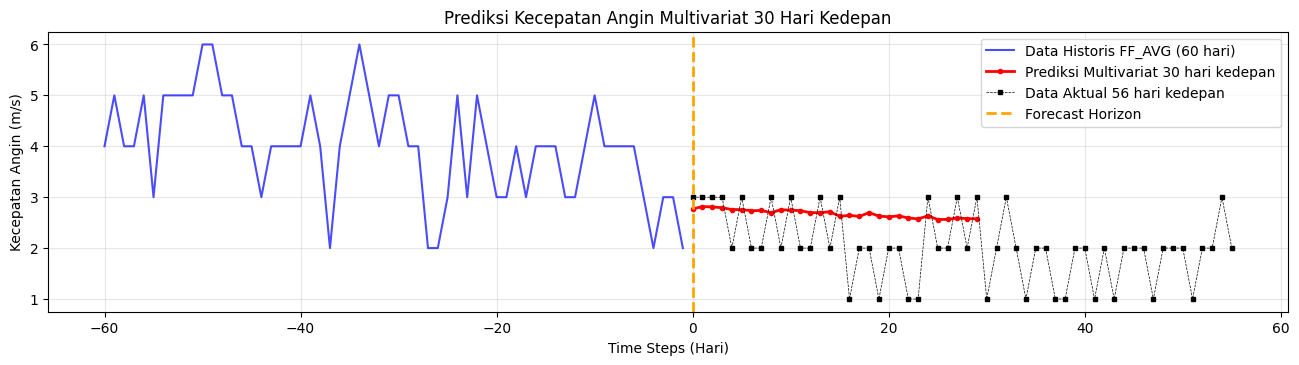

In [37]:
# Visualisasi prediksi masa depan
plt.figure(figsize=(16, 8))

# Plot data historis sebagai konteks (hanya target variable)
context_data = latest_sequence_multivariate[:, 0]  # ambil FF_AVG saja untuk konteks
context_x = range(-len(context_data), 0)
future_x = range(0, len(next_30_forecast_multivariate))
actual_x = range(0, len(array_next_56_actual))

plt.subplot(2, 1, 1)
plt.plot(context_x, context_data, label='Data Historis FF_AVG (60 hari)', color='blue', alpha=0.7)
plt.plot(future_x, next_30_forecast_multivariate, label='Prediksi Multivariat 30 hari kedepan', color='red', linewidth=2, marker='o', markersize=3)
plt.plot(actual_x, array_next_56_actual, label='Data Aktual 56 hari kedepan', color='black', linestyle='--', linewidth=0.5, marker='s', markersize=3)

plt.axvline(x=0, color='orange', linestyle='--', linewidth=2, label='Forecast Horizon')
plt.title('Prediksi Kecepatan Angin Multivariat 30 Hari Kedepan')
plt.xlabel('Time Steps (Hari)')
plt.ylabel('Kecepatan Angin (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)